<a href="https://colab.research.google.com/github/Rima6699/Amir-datmin/blob/main/projek%20kelompok%20data%20mining.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# ══════════════════════════════════════════════════════════════════
# 1. IMPORT LIBRARY
# ══════════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import networkx as nx                            # Visualisasi network graph

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams.update({'figure.dpi': 110, 'figure.facecolor': 'white',
                     'axes.titleweight': 'bold', 'axes.titlesize': 12})

PALETTE_CLUSTER = sns.color_palette('Set2', 6)

def section(title, icon=''):
    bar = '═' * 66
    print(f'\n╔{bar}╗')
    print(f'║  {icon}  {title:<63}║')
    print(f'╚{bar}╝')

def sub(title):
    print(f'\n  ┌─ {title}')

print('✅  Semua library berhasil diimport!')
print('    pandas | numpy | matplotlib | seaborn | sklearn | mlxtend | networkx')


# ══════════════════════════════════════════════════════════════════
# 2. LOAD DATASET
# ══════════════════════════════════════════════════════════════════
section('LOAD DATASET', '📂')

from google.colab import files

# ── File 1: Data Utama ────────────────────────────────────────────
print('\n  📎  Upload File 1: tenaga_kerja_sektor_indonesia.csv')
up1 = files.upload()
FILE_UTAMA = list(up1.keys())[0]
df_raw = pd.read_csv(FILE_UTAMA)

# ── File 2: Data Transaksi ARM ────────────────────────────────────
print('\n  📎  Upload File 2: association_rule_transactions.csv')
up2 = files.upload()
FILE_TRANS = list(up2.keys())[0]
df_trans_raw = pd.read_csv(FILE_TRANS)

print(f'\n  ✅  File 1 — {FILE_UTAMA}')
print(f'      Dimensi : {df_raw.shape[0]:,} baris × {df_raw.shape[1]} kolom')
print(f'\n  ✅  File 2 — {FILE_TRANS}')
print(f'      Dimensi : {df_trans_raw.shape[0]:,} baris × {df_trans_raw.shape[1]} kolom')
print(f'      Kolom   : {list(df_trans_raw.columns)}')

print('\n  ── 5 Teratas — Data Utama ──────────────────────────────')
display(df_raw.head())

print('\n  ── 5 Teratas — Data Transaksi ──────────────────────────')
display(df_trans_raw.head())


✅  Semua library berhasil diimport!
    pandas | numpy | matplotlib | seaborn | sklearn | mlxtend | networkx

╔══════════════════════════════════════════════════════════════════╗
║  📂  LOAD DATASET                                                   ║
╚══════════════════════════════════════════════════════════════════╝

  📎  Upload File 1: tenaga_kerja_sektor_indonesia.csv


Saving tenaga_kerja_sektor_indonesia.csv to tenaga_kerja_sektor_indonesia.csv

  📎  Upload File 2: association_rule_transactions.csv


Saving association_rule_transactions.csv to association_rule_transactions.csv

  ✅  File 1 — tenaga_kerja_sektor_indonesia.csv
      Dimensi : 2,040 baris × 10 kolom

  ✅  File 2 — association_rule_transactions.csv
      Dimensi : 204 baris × 4 kolom
      Kolom   : ['ID', 'Tahun', 'Provinsi', 'Itemset']

  ── 5 Teratas — Data Utama ──────────────────────────────


,Tahun,Provinsi,Sektor,TenagaKerjaMuda,KontribusiPDB,Pertumbuhan,Digitalisasi,Produktivitas,RasioUpahProduktivitas,SkillTeknis
0,2019,Aceh,Pertanian,83973,3.7900,19.9800,42.6200,28.6000,0.7200,51.0500
1,2019,Aceh,Industri Pengolahan,71139,7.3000,54.8500,67.6800,57.2100,0.7800,51.6100
2,2019,Aceh,Perdagangan,56200,5.1600,57.9800,61.5700,49.5500,0.5800,60.2600
3,2019,Aceh,Pariwisata,58193,10.1000,47.4900,62.2800,50.6700,0.6100,47.6300
4,2019,Aceh,Ekonomi Kreatif,70194,11.5600,66.4800,87.2600,61.9200,0.6200,75.7600



  ── 5 Teratas — Data Transaksi ──────────────────────────


,ID,Tahun,Provinsi,Itemset
0,1,2019,Aceh,"Pertanian,Perdagangan,Ekonomi Kreatif,Industri..."
1,2,2019,Sumut,"Perdagangan,Industri Pengolahan"
2,3,2019,Sumbar,"UMKM Digital,Perdagangan,Jasa Pendidikan,Indus..."
3,4,2019,Riau,"Pariwisata,Perdagangan,Industri Pengolahan"
4,5,2019,Jambi,"Pariwisata,Perdagangan,Konstruksi,Industri Pen..."



╔══════════════════════════════════════════════════════════════════╗
║  🔍  EXPLORATORY DATA ANALYSIS (EDA)                                ║
╚══════════════════════════════════════════════════════════════════╝

  ┌─ 3.1  Info Dataset
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2040 entries, 0 to 2039
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Tahun                   2040 non-null   int64  
 1   Provinsi                2040 non-null   object 
 2   Sektor                  2040 non-null   object 
 3   TenagaKerjaMuda         2040 non-null   int64  
 4   KontribusiPDB           2040 non-null   float64
 5   Pertumbuhan             2040 non-null   float64
 6   Digitalisasi            2040 non-null   float64
 7   Produktivitas           2040 non-null   float64
 8   RasioUpahProduktivitas  2040 non-null   float64
 9   SkillTeknis             2040 non-null   float64
dtypes: float64(6), int

,count,mean,std,min,25%,50%,75%,max
TenagaKerjaMuda,2040.00,80039.94,23306.44,30053.00,64675.00,76315.50,88545.25,164330.00
KontribusiPDB,2040.00,8.41,3.60,0.50,5.70,7.83,10.96,19.39
Pertumbuhan,2040.00,55.86,16.16,16.11,50.33,56.81,68.13,83.68
Digitalisasi,2040.00,71.28,14.19,24.51,64.98,72.63,80.74,100.00
Produktivitas,2040.00,55.96,11.58,14.28,51.49,57.47,63.30,86.32
RasioUpahProduktivitas,2040.00,0.75,0.12,0.28,0.67,0.76,0.83,1.16
SkillTeknis,2040.00,58.79,15.09,23.32,46.61,57.72,69.28,100.00



  ┌─ 3.4  Histogram Distribusi Numerik


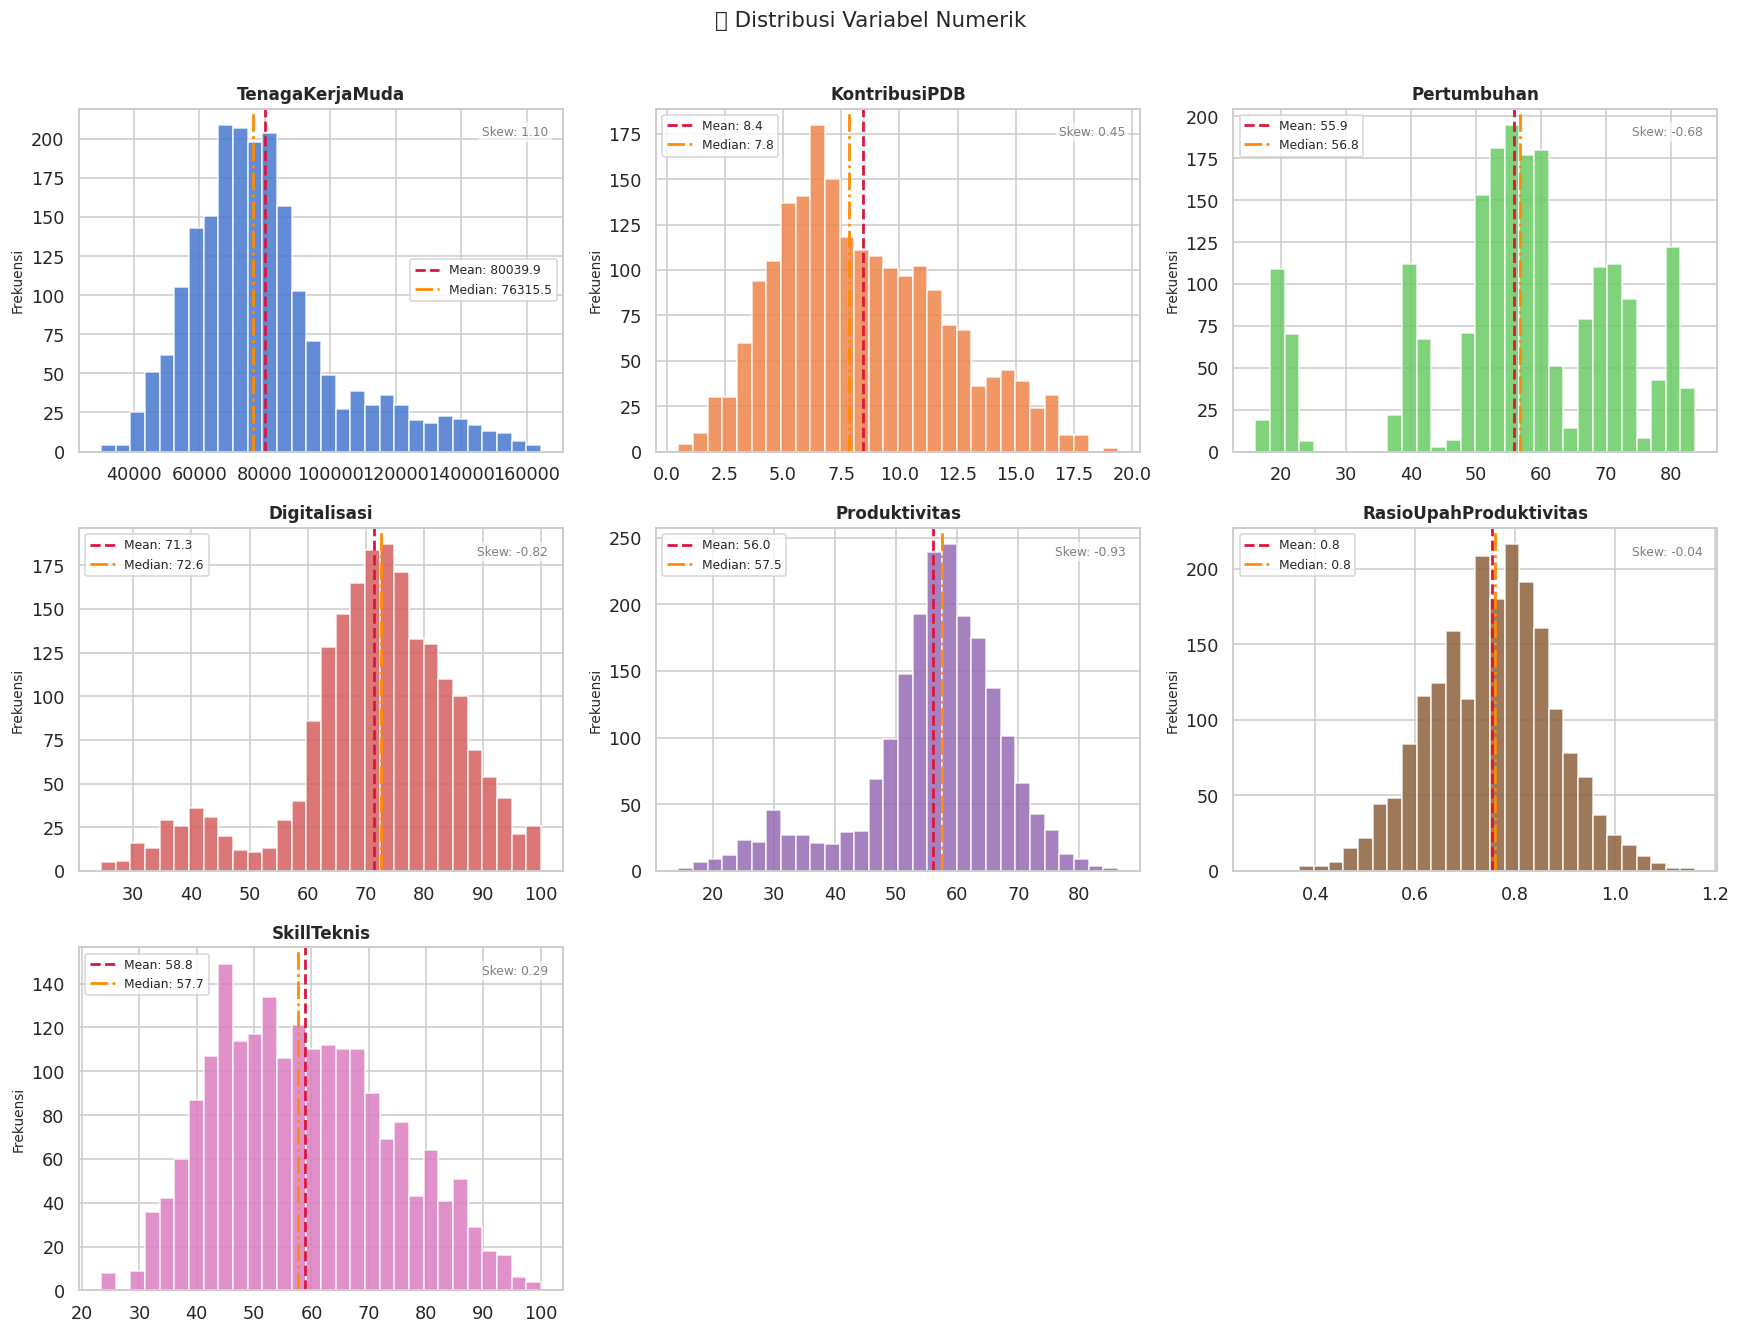


  💡 TenagaKerjaMuda right-skewed → provinsi Jawa jauh di atas rata-rata.
     Digitalisasi & SkillTeknis mendekati normal → variasi merata antar provinsi.

  ┌─ 3.5  Boxplot Deteksi Outlier


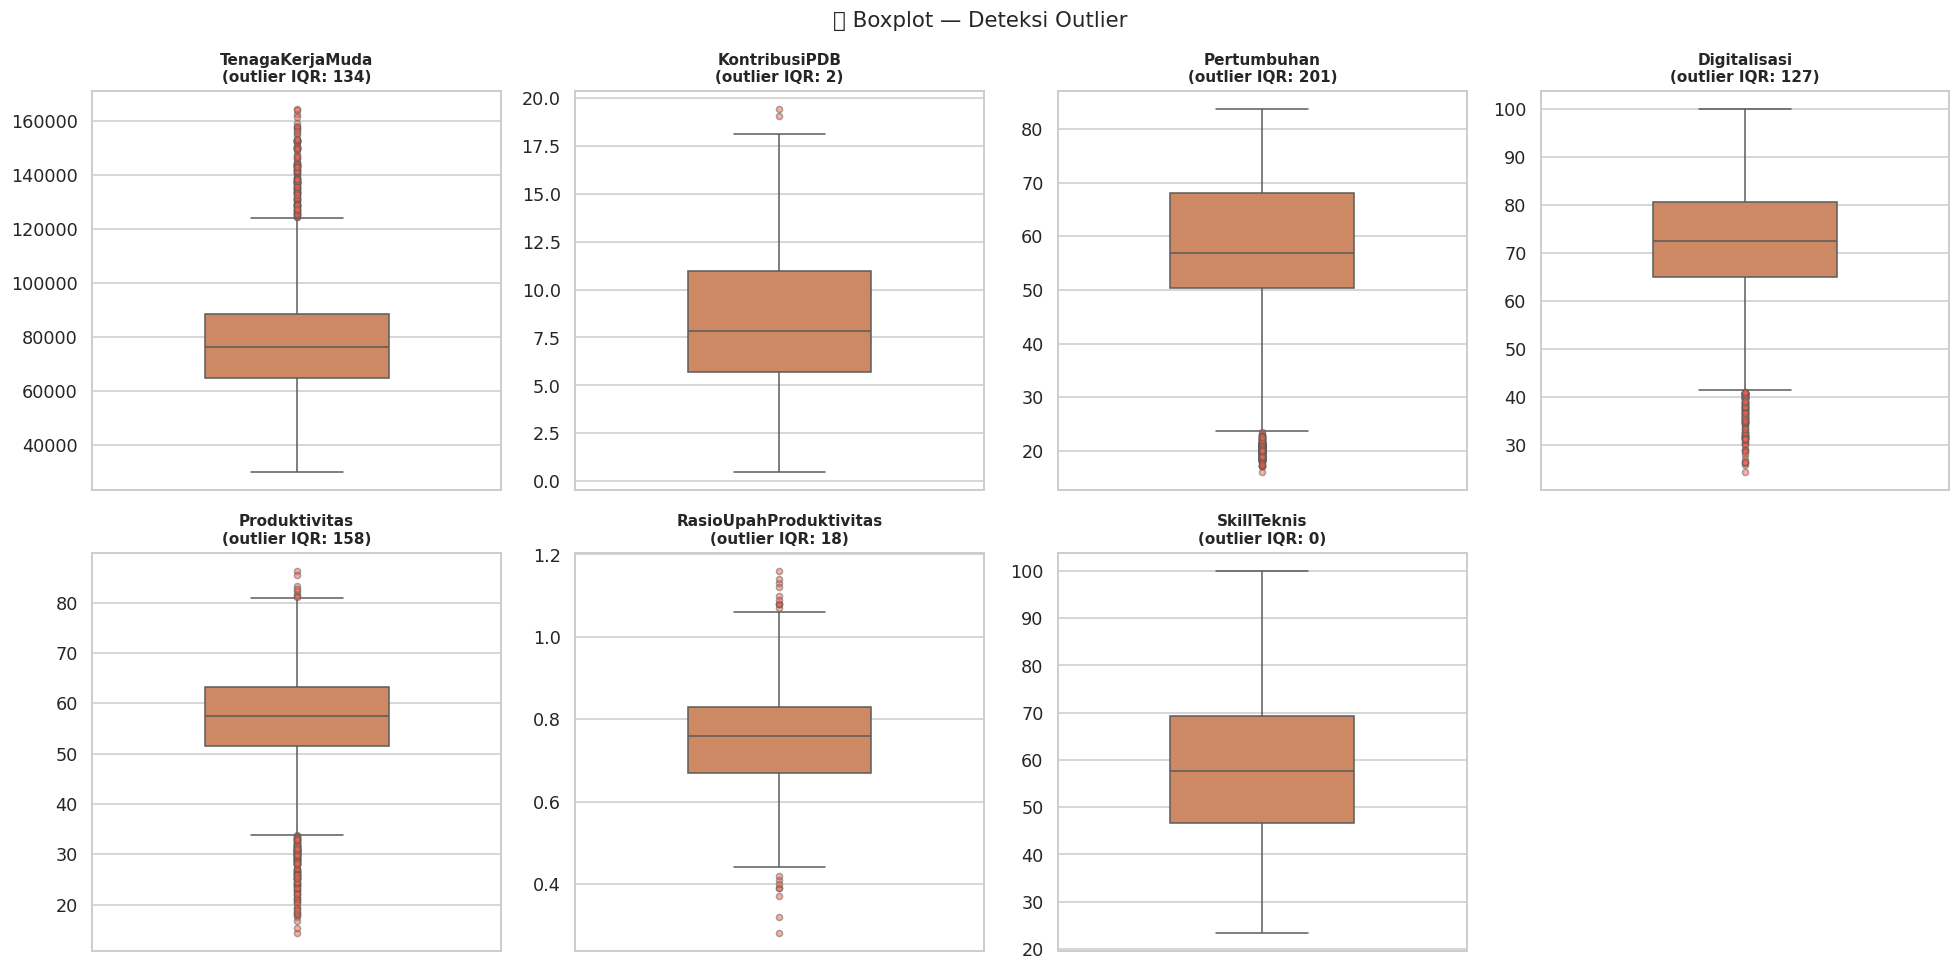


  💡 TenagaKerjaMuda memiliki outlier atas → provinsi padat (Jawa).

  ┌─ 3.6  Tren Tahunan Indikator Utama (2019–2024)


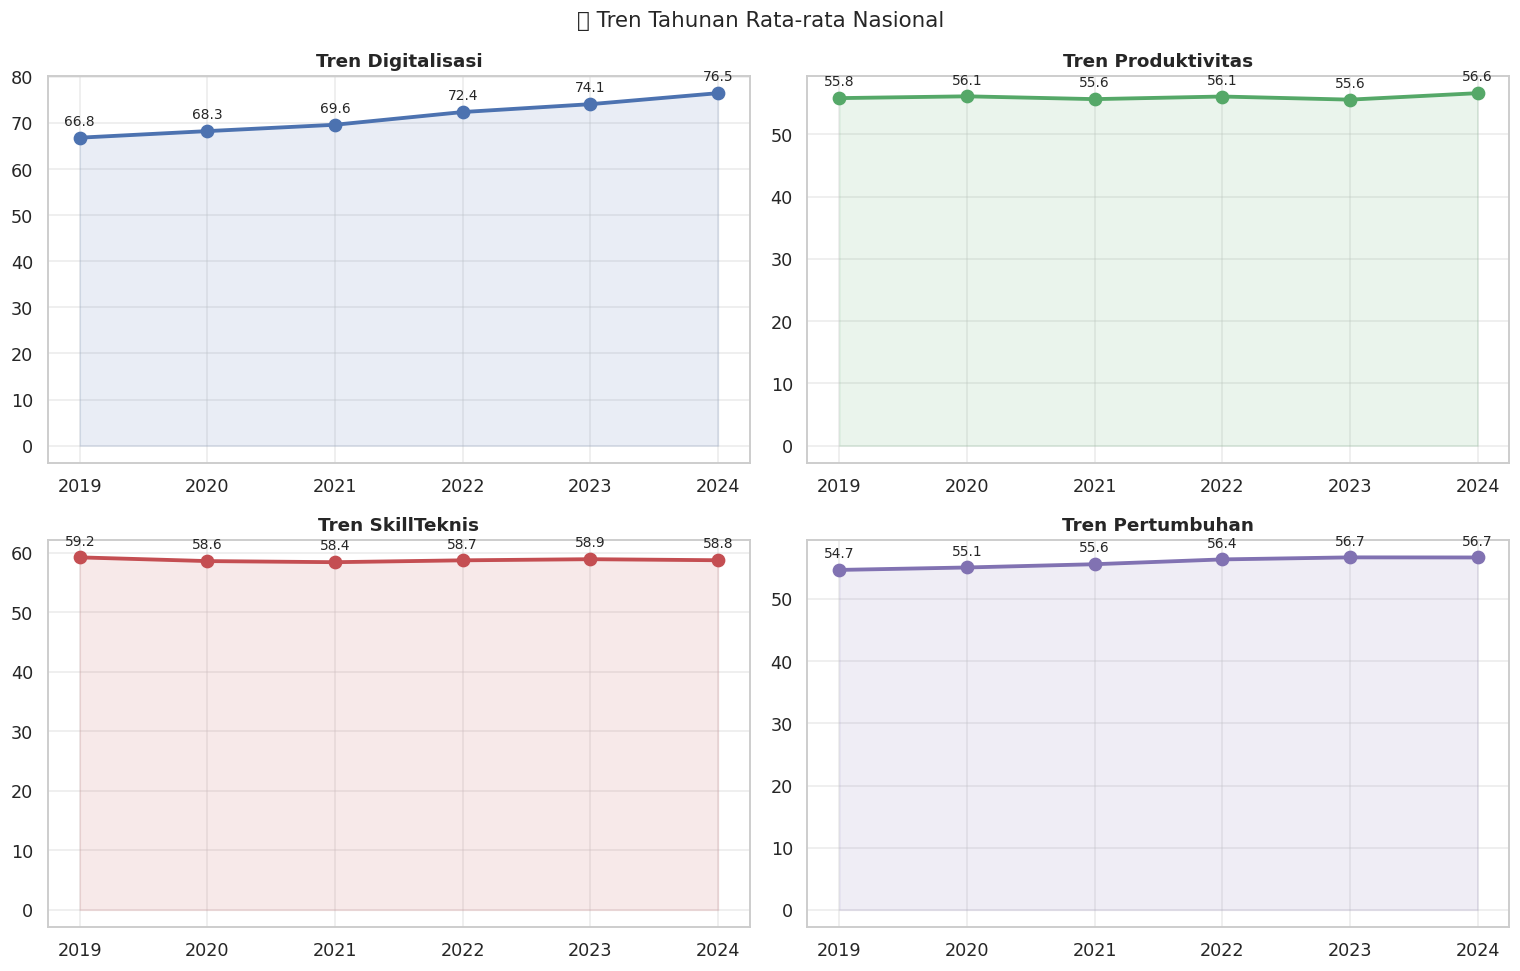


  💡 Digitalisasi & SkillTeknis konsisten meningkat 2019–2024.

  ┌─ 3.7  Rata-rata Indikator per Sektor


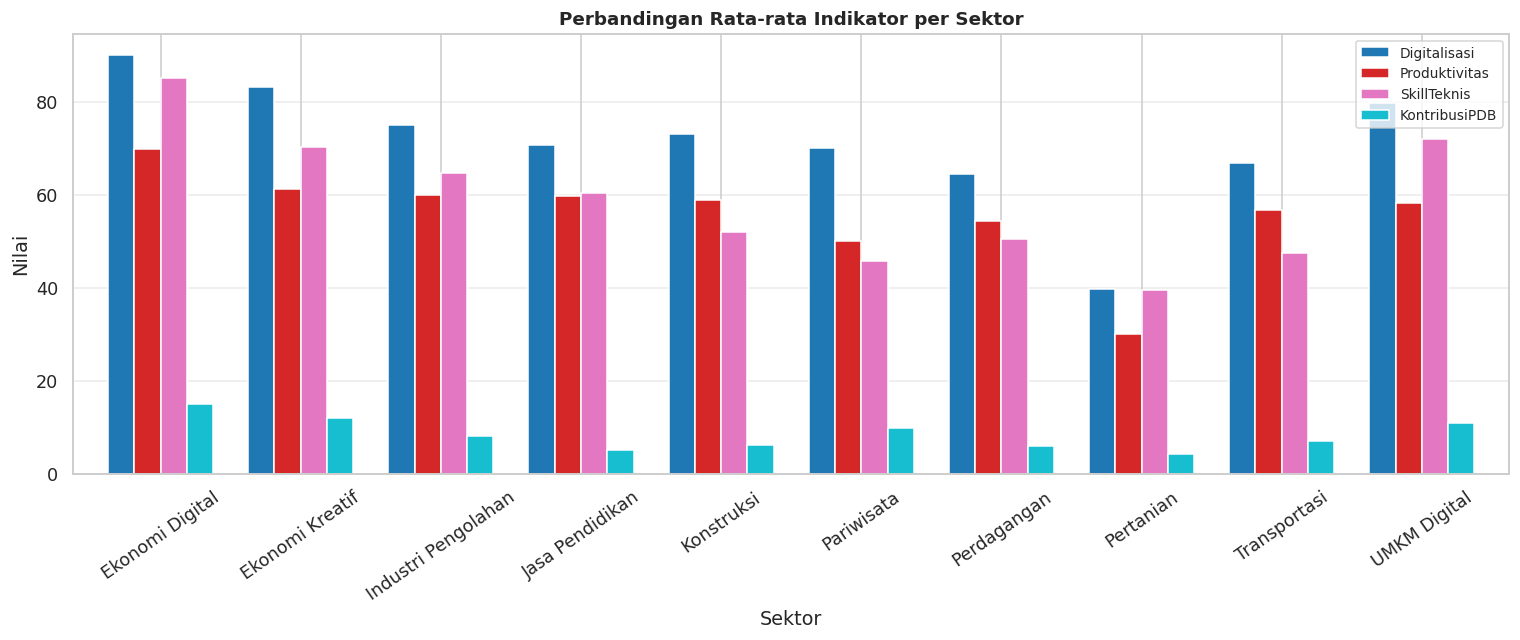


  💡 Ekonomi Digital & Ekonomi Kreatif dominan di Digitalisasi & SkillTeknis.
     Pertanian konsisten terendah di semua indikator.

  ┌─ 3.8  Heatmap Korelasi


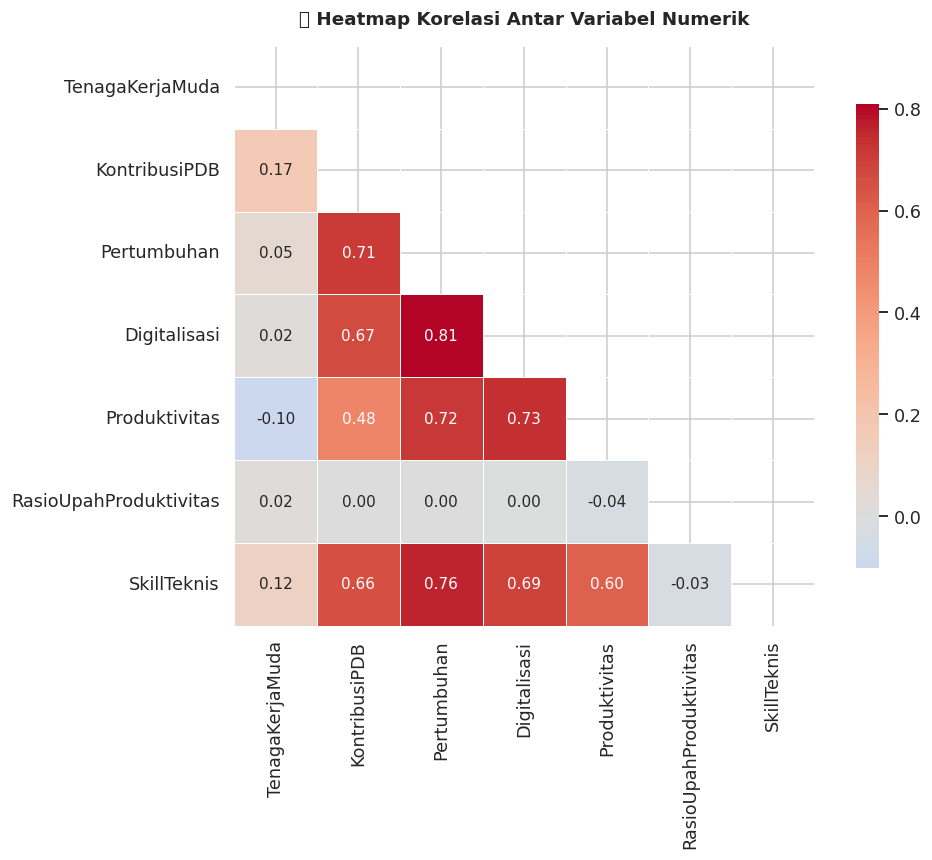


  💡 Digitalisasi ↔ SkillTeknis : korelasi positif kuat.
     Produktivitas ↔ KontribusiPDB : korelasi positif sedang.

╔══════════════════════════════════════════════════════════════════╗
║  ⚙️  PREPROCESSING DATA                                             ║
╚══════════════════════════════════════════════════════════════════╝

  ┌─ 4.1  Hapus Duplikat
  Dihapus: 0 baris  |  Sisa: 2,040 baris

  ┌─ 4.2  Imputasi Missing Values
  ✅ Missing tersisa: 0

  ┌─ 4.3  Label Encoding Kategorikal
  ✅ Provinsi & Sektor → Label Encoded

  ┌─ 4.4  Standardisasi (StandardScaler)
  ✅ 7 fitur numerik di-standardisasi


,mean,std,min,max
TenagaKerjaMuda,-0.0000,1.0002,-2.1453,3.6175
KontribusiPDB,0.0000,1.0002,-2.2007,3.0520
Pertumbuhan,-0.0000,1.0002,-2.4606,1.7219
Digitalisasi,0.0000,1.0002,-3.2967,2.0244
Produktivitas,-0.0000,1.0002,-3.5992,2.6218
RasioUpahProduktivitas,-0.0000,1.0002,-3.9003,3.3392
SkillTeknis,0.0000,1.0002,-2.3510,2.7318



╔══════════════════════════════════════════════════════════════════╗
║  🎯  MENENTUKAN JUMLAH CLUSTER OPTIMAL                              ║
╚══════════════════════════════════════════════════════════════════╝


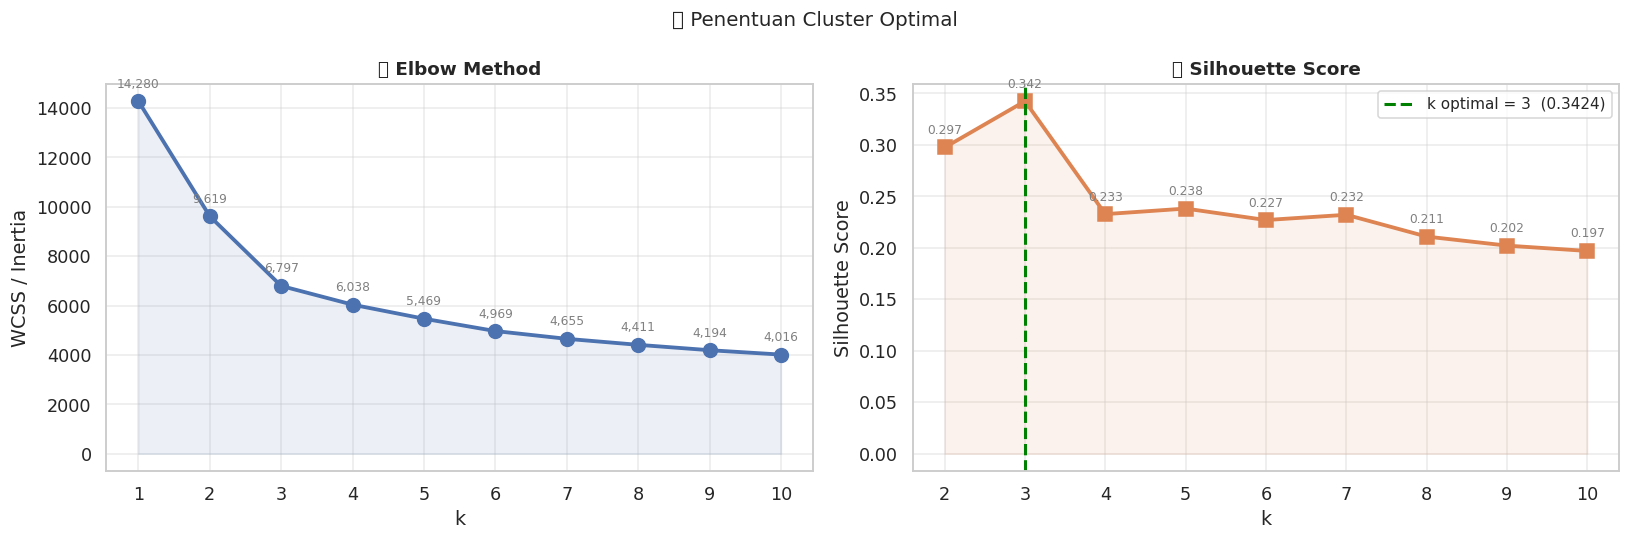

,k,Silhouette Score
0,2,0.297400
1,3,0.342400
2,4,0.232700
3,5,0.238100
4,6,0.226900
5,7,0.232100
6,8,0.210900
7,9,0.202100
8,10,0.196900



  ✅  k OPTIMAL = 3  |  Silhouette Score: 0.3424

╔══════════════════════════════════════════════════════════════════╗
║  🤖  K-MEANS CLUSTERING                                             ║
╚══════════════════════════════════════════════════════════════════╝

  ┌─ Distribusi Anggota per Cluster
  Cluster 0 │ █████████████████████████████│ 1,200 (58.8%)
  Cluster 1 │ █████                     │   204 (10.0%)
  Cluster 2 │ ███████████████           │   636 (31.2%)

  Silhouette Score : 0.3424
  Inertia (WCSS)   : 6,796.70

  ┌─ Visualisasi Cluster — PCA 2D


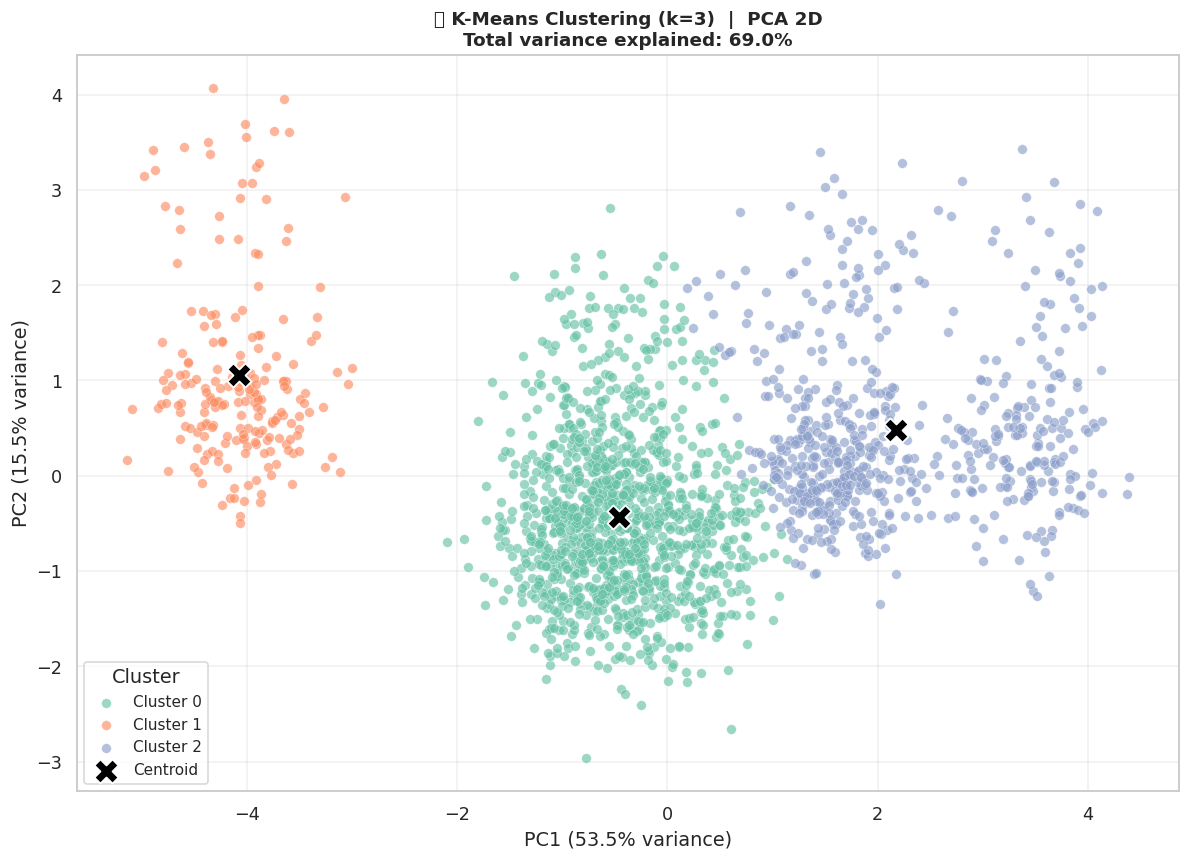


  ┌─ Komposisi Cluster per Sektor


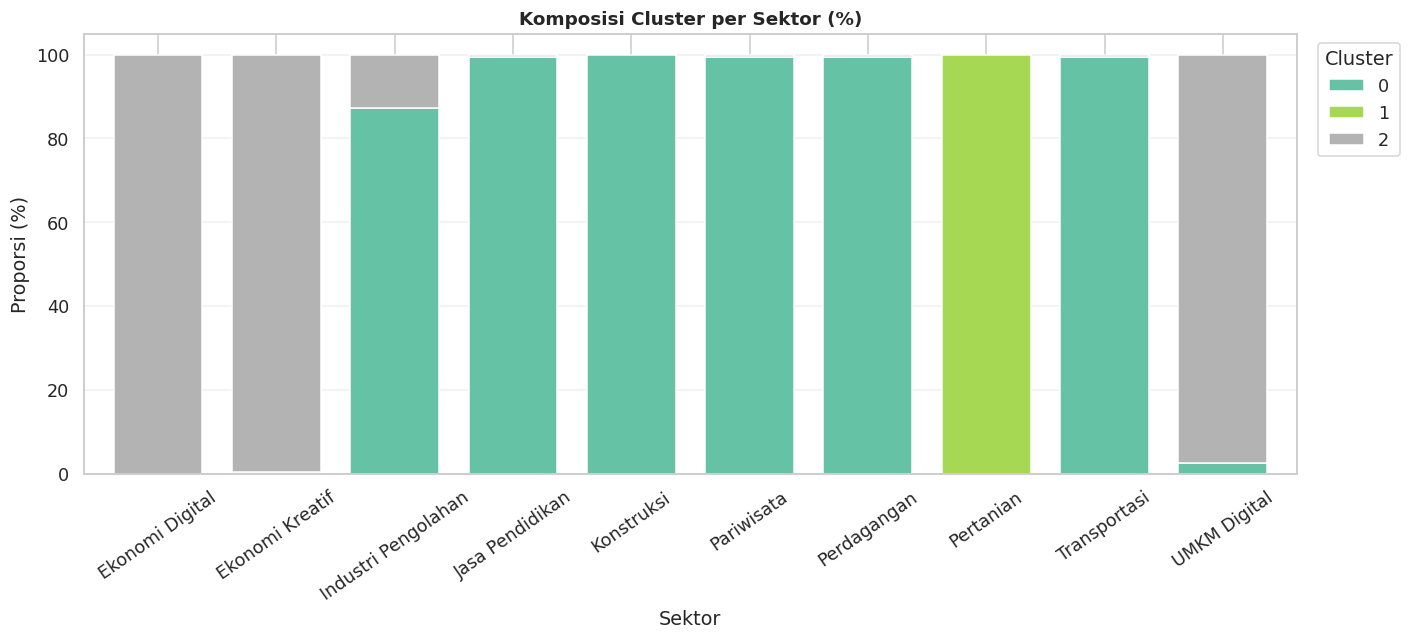


╔══════════════════════════════════════════════════════════════════╗
║  📋  ANALISIS PROFIL CLUSTER                                        ║
╚══════════════════════════════════════════════════════════════════╝

  ┌─ 7.1  Rata-rata Fitur per Cluster


cluster,0,1,2
TenagaKerjaMuda,71744.978,96028.436,90562.420
KontribusiPDB,6.989,4.173,12.465
Pertumbuhan,52.984,20.193,72.733
Digitalisasi,69.806,39.708,84.189
Produktivitas,56.554,30.142,63.117
RasioUpahProduktivitas,0.753,0.753,0.757
SkillTeknis,53.155,39.515,75.596



  ┌─ 7.2  Radar Chart


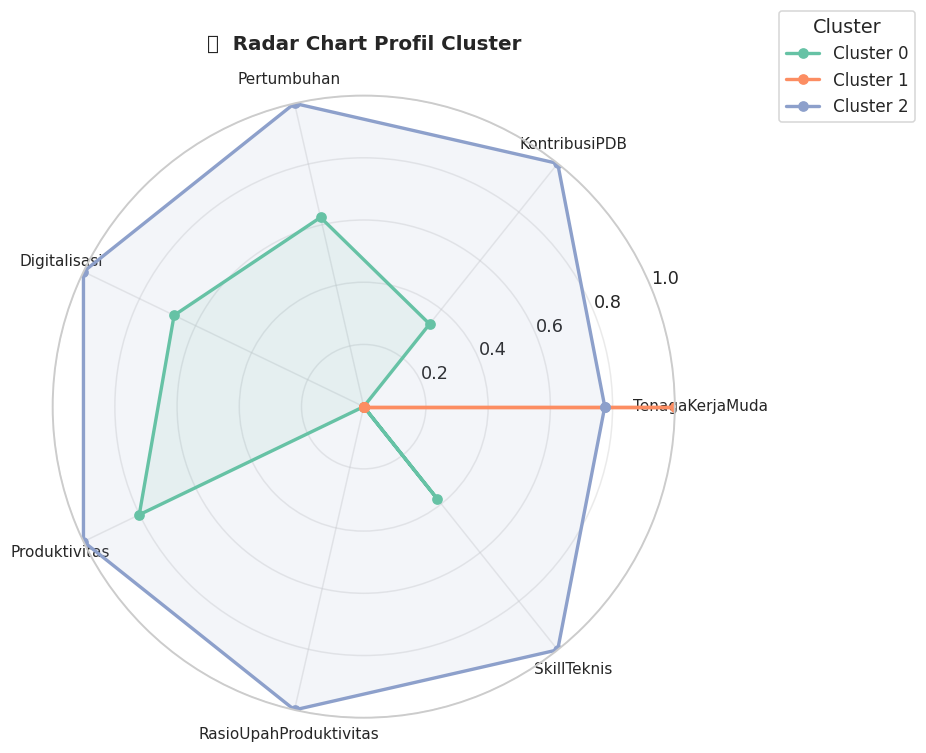


  ┌─ 7.3  Interpretasi Profil Cluster

  ▶  Cluster 0 — [TRANSISI]  (1,200 data / 58.8%)
     Top sektor           : ['Konstruksi', 'Perdagangan', 'Transportasi']
     Digitalisasi rata2   : 69.81
     SkillTeknis rata2    : 53.16
     Produktivitas rata2  : 56.55
     KontribusiPDB rata2  : 6.99
     ↑ Di atas rata-rata  : Pertumbuhan, Digitalisasi, Produktivitas
     ↓ Di bawah rata-rata : TenagaKerjaMuda, KontribusiPDB, RasioUpahProduktivitas, SkillTeknis

  ▶  Cluster 1 — [TRADISIONAL]  (204 data / 10.0%)
     Top sektor           : ['Pertanian']
     Digitalisasi rata2   : 39.71
     SkillTeknis rata2    : 39.52
     Produktivitas rata2  : 30.14
     KontribusiPDB rata2  : 4.17
     ↑ Di atas rata-rata  : TenagaKerjaMuda
     ↓ Di bawah rata-rata : KontribusiPDB, Pertumbuhan, Digitalisasi, Produktivitas, RasioUpahProduktivitas, SkillTeknis

  ▶  Cluster 2 — [MAJU / DIGITAL]  (636 data / 31.2%)
     Top sektor           : ['Ekonomi Digital', 'Ekonomi Kreatif', 'UMKM Digital']
    

,ID,Tahun,Provinsi,Itemset
0,1,2019,Aceh,"Pertanian,Perdagangan,Ekonomi Kreatif,Industri..."
1,2,2019,Sumut,"Perdagangan,Industri Pengolahan"
2,3,2019,Sumbar,"UMKM Digital,Perdagangan,Jasa Pendidikan,Indus..."
3,4,2019,Riau,"Pariwisata,Perdagangan,Industri Pengolahan"
4,5,2019,Jambi,"Pariwisata,Perdagangan,Konstruksi,Industri Pen..."
5,6,2019,Sumsel,"Pariwisata,Pertanian,Transportasi,Industri Pen..."
6,7,2019,Bengkulu,"Pertanian,Perdagangan,Industri Pengolahan"
7,8,2019,Lampung,"Pertanian,Ekonomi Kreatif,Ekonomi Digital,Indu..."



  ┌─ 8.2  Frekuensi Item (Sektor) dalam Transaksi


,Sektor,Frekuensi,Support (%)
0,Industri Pengolahan,137,67.160000
1,Perdagangan,130,63.730000
2,Pertanian,124,60.780000
3,UMKM Digital,64,31.370000
4,Ekonomi Kreatif,63,30.880000
5,Ekonomi Digital,55,26.960000
6,Pariwisata,45,22.060000
7,Konstruksi,42,20.590000
8,Transportasi,42,20.590000
9,Jasa Pendidikan,33,16.180000


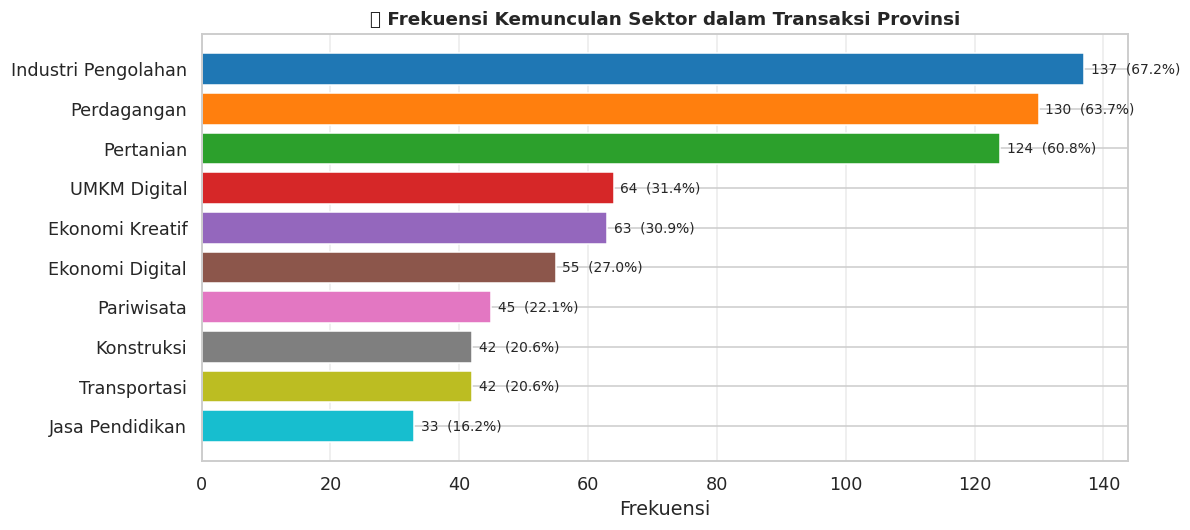


  💡 Industri Pengolahan & Perdagangan adalah sektor paling sering
     muncul bersama dalam satu transaksi provinsi.

  ┌─ 8.3  Konversi ke Format One-Hot
  ✅  Format one-hot siap.
     Baris × Kolom : (204, 10)
     Item (Sektor) : ['Ekonomi Digital', 'Ekonomi Kreatif', 'Industri Pengolahan', 'Jasa Pendidikan', 'Konstruksi', 'Pariwisata', 'Perdagangan', 'Pertanian', 'Transportasi', 'UMKM Digital']


,Ekonomi Digital,Ekonomi Kreatif,Industri Pengolahan,Jasa Pendidikan,Konstruksi,Pariwisata,Perdagangan,Pertanian,Transportasi,UMKM Digital
0,False,True,True,False,False,False,True,True,False,False
1,False,False,True,False,False,False,True,False,False,False
2,False,False,True,True,False,False,True,False,False,True
3,False,False,True,False,False,True,True,False,False,False
4,False,False,True,False,True,True,True,False,False,False



  ┌─ 8.4  Frequent Itemsets (min_support = 0.10)
  Jumlah frequent itemsets : 35

  ── 1-itemset (top 10) ──


,itemsets,support
2,frozenset({'Industri Pengolahan'}),0.6716
6,frozenset({'Perdagangan'}),0.6373
7,frozenset({'Pertanian'}),0.6078
9,frozenset({'UMKM Digital'}),0.3137
1,frozenset({'Ekonomi Kreatif'}),0.3088
0,frozenset({'Ekonomi Digital'}),0.2696
5,frozenset({'Pariwisata'}),0.2206
4,frozenset({'Konstruksi'}),0.2059
8,frozenset({'Transportasi'}),0.2059
3,frozenset({'Jasa Pendidikan'}),0.1618



  ── 2-itemset (top 10) ──


...


  ── 3-itemset (top 10) ──


,itemsets,support
34,"frozenset({'Perdagangan', 'Pertanian', 'Industri Pengolahan'})",0.1618



  ┌─ 8.5  Association Rules (confidence ≥ 0.50)
  Jumlah rules ditemukan : 19


,antecedents,consequents,support,confidence,lift
13,frozenset({'Pariwisata'}),frozenset({'Pertanian'}),0.1569,0.7111,1.1699
1,frozenset({'Jasa Pendidikan'}),frozenset({'Industri Pengolahan'}),0.1176,0.7273,1.0829
10,frozenset({'Jasa Pendidikan'}),frozenset({'Pertanian'}),0.1029,0.6364,1.0469
16,frozenset({'Transportasi'}),frozenset({'Perdagangan'}),0.1324,0.6429,1.0088
3,frozenset({'Pariwisata'}),frozenset({'Industri Pengolahan'}),0.1471,0.6667,0.9927
18,frozenset({'Transportasi'}),frozenset({'Pertanian'}),0.1225,0.5952,0.9793
6,frozenset({'Pertanian'}),frozenset({'Industri Pengolahan'}),0.3922,0.6452,0.9607
7,frozenset({'Industri Pengolahan'}),frozenset({'Pertanian'}),0.3922,0.5839,0.9607
15,frozenset({'Pertanian'}),frozenset({'Perdagangan'}),0.3676,0.6048,0.9491
14,frozenset({'Perdagangan'}),frozenset({'Pertanian'}),0.3676,0.5769,0.9491



  ┌─ 8.6  Visualisasi Association Rules


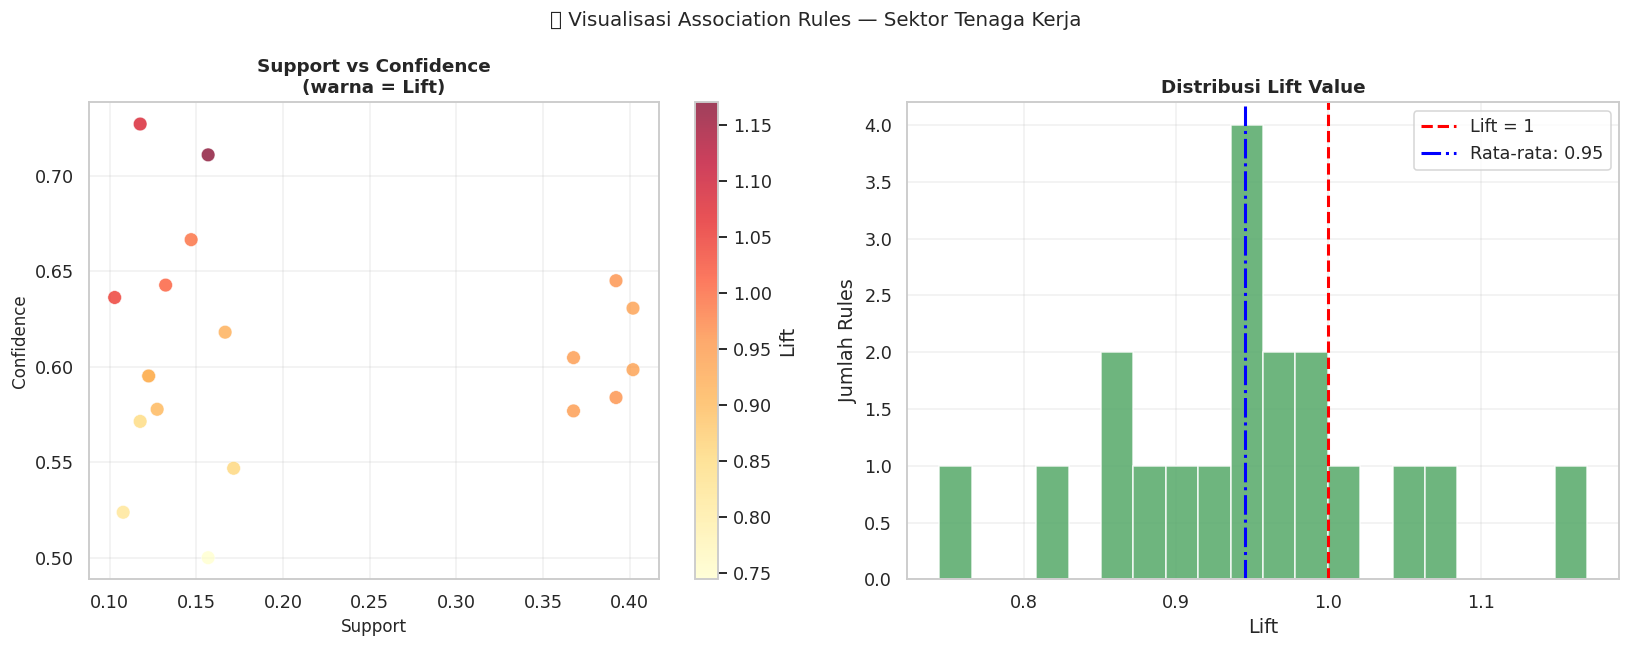


  ┌─ 8.7  Network Graph — Hubungan Antar Sektor (Top Rules by Lift)


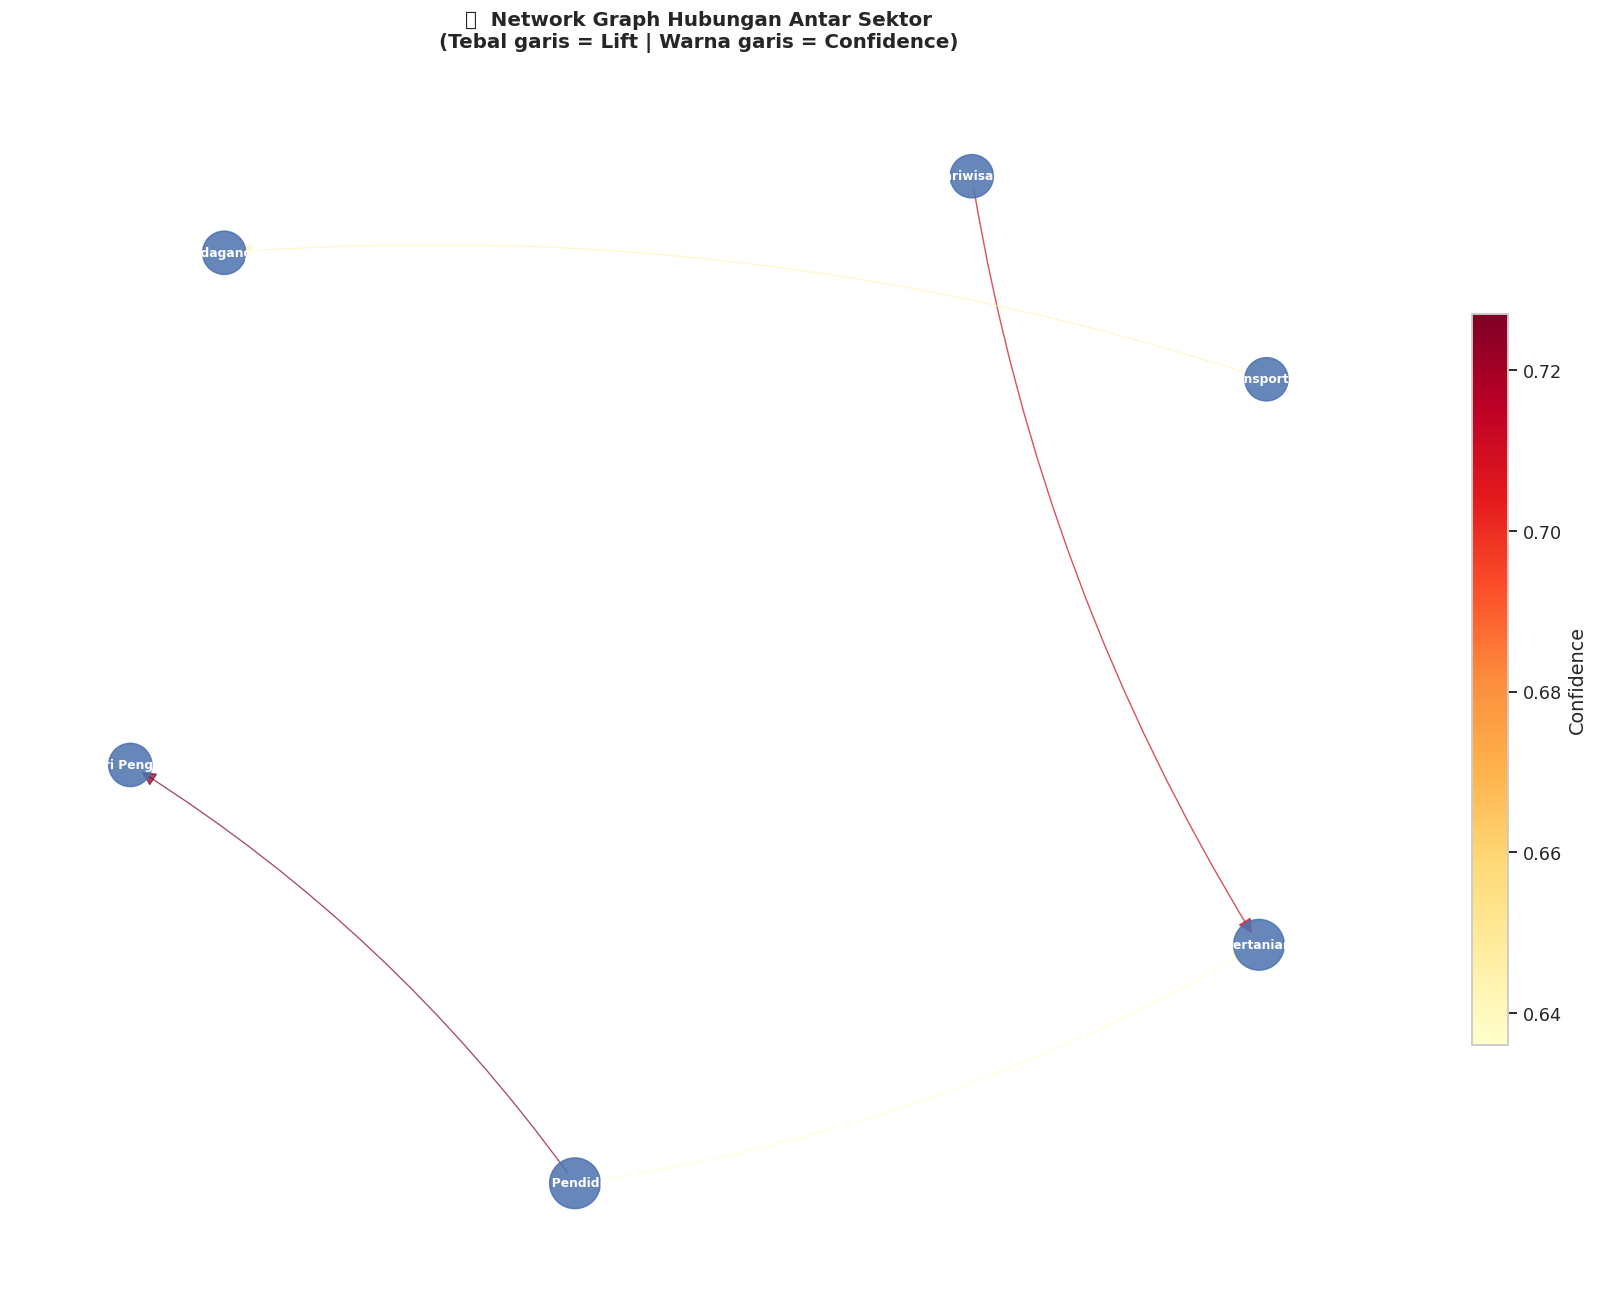


  💡 Node besar = sektor sering muncul sebagai antecedent/consequent.
     Garis tebal & merah = hubungan kuat (lift & confidence tinggi).

  ┌─ 8.8  Top 10 Rules Terkuat & Insight Bisnis

   1. JIKA  [Pariwisata]
      MAKA  [Pertanian]
       Support: 0.1569 | Conf: 0.7111 | Lift: 1.1699

   2. JIKA  [Jasa Pendidikan]
      MAKA  [Industri Pengolahan]
       Support: 0.1176 | Conf: 0.7273 | Lift: 1.0829

   3. JIKA  [Jasa Pendidikan]
      MAKA  [Pertanian]
       Support: 0.1029 | Conf: 0.6364 | Lift: 1.0469

   4. JIKA  [Transportasi]
      MAKA  [Perdagangan]
       Support: 0.1324 | Conf: 0.6429 | Lift: 1.0088

   5. JIKA  [Pariwisata]
      MAKA  [Industri Pengolahan]
       Support: 0.1471 | Conf: 0.6667 | Lift: 0.9927

   6. JIKA  [Transportasi]
      MAKA  [Pertanian]
       Support: 0.1225 | Conf: 0.5952 | Lift: 0.9793

   7. JIKA  [Pertanian]
      MAKA  [Industri Pengolahan]
       Support: 0.3922 | Conf: 0.6452 | Lift: 0.9607

   8. JIKA  [Industri Pengolahan]
      MAKA 

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ✅  Disimpan & didownload: hasil_clustering_tenaga_kerja.csv
     2,040 baris × 13 kolom


,Tahun,Provinsi,Sektor,TenagaKerjaMuda,KontribusiPDB,Pertumbuhan,Digitalisasi,Produktivitas,RasioUpahProduktivitas,SkillTeknis,Provinsi_enc,Sektor_enc,cluster
0,2019,Aceh,Pertanian,83973,3.7900,19.9800,42.6200,28.6000,0.7200,51.0500,0,7,1
1,2019,Aceh,Industri Pengolahan,71139,7.3000,54.8500,67.6800,57.2100,0.7800,51.6100,0,2,0
2,2019,Aceh,Perdagangan,56200,5.1600,57.9800,61.5700,49.5500,0.5800,60.2600,0,6,0



╔══════════════════════════════════════════════════════════════════╗
║  📝  KESIMPULAN ANALISIS DATA                                       ║
╚══════════════════════════════════════════════════════════════════╝

  ╔═══════════════════════════════════════════════════════════════╗
  ║       RINGKASAN PIPELINE — TENAGA KERJA SEKTOR INDONESIA      ║
  ╠═══════════════════════════════════════════════════════════════╣
  ║  Sumber Data  :                                               ║
  ║    File 1 → tenaga_kerja_sektor_indonesia.csv                 ║
  ║             (2.040 baris | 34 provinsi | 10 sektor | 6 tahun) ║
  ║    File 2 → association_rule_transactions.csv                 ║
  ║             (204 transaksi sektor nyata per provinsi/tahun)   ║
  ╠═══════════════════════════════════════════════════════════════╣
  ║                                                               ║
  ║  ✅  EDA                                                      ║
  ║      Tidak ada missing values / duplik

In [3]:
# ══════════════════════════════════════════════════════════════════
# 3. EXPLORATORY DATA ANALYSIS (EDA)
# ══════════════════════════════════════════════════════════════════
section('EXPLORATORY DATA ANALYSIS (EDA)', '🔍')

df = df_raw.copy()

NUM_COLS = ['TenagaKerjaMuda', 'KontribusiPDB', 'Pertumbuhan',
            'Digitalisasi', 'Produktivitas', 'RasioUpahProduktivitas', 'SkillTeknis']
CAT_COLS = ['Provinsi', 'Sektor']

# ── 3.1  Info & Missing ───────────────────────────────────────────
sub('3.1  Info Dataset')
df.info()

sub('3.2  Missing Values & Duplikasi')
mv = df.isnull().sum().sum()
dup = df.duplicated().sum()
print(f'  Missing values : {mv}  →  {"✅ Bersih" if mv == 0 else "⚠️ Ada missing"}')
print(f'  Duplikasi      : {dup}  →  {"✅ Bersih" if dup == 0 else "⚠️ Ada duplikat"}')

sub('3.3  Statistik Deskriptif — Numerik')
display(df[NUM_COLS].describe().T
        .style.background_gradient(cmap='Blues', axis=1).format('{:.2f}'))

# ── 3.4  Histogram ────────────────────────────────────────────────
sub('3.4  Histogram Distribusi Numerik')
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()
colors_h = sns.color_palette('muted', len(NUM_COLS))

for i, col in enumerate(NUM_COLS):
    ax = axes[i]
    data = df[col]
    ax.hist(data, bins=30, color=colors_h[i], edgecolor='white', alpha=0.85)
    ax.axvline(data.mean(),   color='crimson',   ls='--', lw=1.8,
               label=f'Mean: {data.mean():.1f}')
    ax.axvline(data.median(), color='darkorange', ls='-.', lw=1.8,
               label=f'Median: {data.median():.1f}')
    ax.set_title(col, fontsize=11)
    ax.set_ylabel('Frekuensi', fontsize=9)
    ax.legend(fontsize=8)
    ax.text(0.97, 0.95, f'Skew: {data.skew():.2f}',
            transform=ax.transAxes, ha='right', va='top', fontsize=8,
            color='gray', bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.6))

axes[-1].set_visible(False)
axes[-2].set_visible(False)
fig.suptitle('📊 Distribusi Variabel Numerik', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()
print('\n  💡 TenagaKerjaMuda right-skewed → provinsi Jawa jauh di atas rata-rata.')
print('     Digitalisasi & SkillTeknis mendekati normal → variasi merata antar provinsi.')

# ── 3.5  Boxplot ──────────────────────────────────────────────────
sub('3.5  Boxplot Deteksi Outlier')
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()
for i, col in enumerate(NUM_COLS):
    ax = axes[i]
    sns.boxplot(y=df[col], ax=ax, color='#DD8452', width=0.45,
                flierprops=dict(marker='o', markerfacecolor='tomato',
                                markersize=4, alpha=0.5))
    Q1, Q3 = df[col].quantile(.25), df[col].quantile(.75)
    IQR = Q3 - Q1
    n_out = ((df[col] < Q1-1.5*IQR) | (df[col] > Q3+1.5*IQR)).sum()
    ax.set_title(f'{col}\n(outlier IQR: {n_out})', fontsize=10)
    ax.set_ylabel('')
axes[-1].set_visible(False)
fig.suptitle('📦 Boxplot — Deteksi Outlier', fontsize=14)
plt.tight_layout()
plt.show()
print('\n  💡 TenagaKerjaMuda memiliki outlier atas → provinsi padat (Jawa).')

# ── 3.6  Tren Tahunan ─────────────────────────────────────────────
sub('3.6  Tren Tahunan Indikator Utama (2019–2024)')
yearly = df.groupby('Tahun')[NUM_COLS].mean().reset_index()
indikator_tren = ['Digitalisasi', 'Produktivitas', 'SkillTeknis', 'Pertumbuhan']
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()
colors_t = ['#4C72B0','#55A868','#C44E52','#8172B2']
for i, col in enumerate(indikator_tren):
    ax = axes[i]
    ax.plot(yearly['Tahun'], yearly[col], 'o-',
            color=colors_t[i], lw=2.5, ms=8)
    ax.fill_between(yearly['Tahun'], yearly[col], alpha=0.12, color=colors_t[i])
    for x, y in zip(yearly['Tahun'], yearly[col]):
        ax.annotate(f'{y:.1f}', (x, y), textcoords='offset points',
                    xytext=(0, 8), ha='center', fontsize=9)
    ax.set_title(f'Tren {col}')
    ax.set_xticks(yearly['Tahun'])
    ax.grid(alpha=0.4)
fig.suptitle('📈 Tren Tahunan Rata-rata Nasional', fontsize=14)
plt.tight_layout()
plt.show()
print('\n  💡 Digitalisasi & SkillTeknis konsisten meningkat 2019–2024.')

# ── 3.7  Perbandingan Sektor ──────────────────────────────────────
sub('3.7  Rata-rata Indikator per Sektor')
sektor_mean = df.groupby('Sektor')[['Digitalisasi','Produktivitas',
                                     'SkillTeknis','KontribusiPDB']].mean()
fig, ax = plt.subplots(figsize=(14, 6))
sektor_mean.plot(kind='bar', ax=ax, colormap='tab10',
                 edgecolor='white', width=0.75)
ax.set_title('Perbandingan Rata-rata Indikator per Sektor')
ax.set_xlabel('Sektor')
ax.set_ylabel('Nilai')
ax.legend(loc='upper right', fontsize=9)
ax.tick_params(axis='x', rotation=35)
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()
print('\n  💡 Ekonomi Digital & Ekonomi Kreatif dominan di Digitalisasi & SkillTeknis.')
print('     Pertanian konsisten terendah di semua indikator.')

# ── 3.8  Heatmap Korelasi ─────────────────────────────────────────
sub('3.8  Heatmap Korelasi')
corr = df[NUM_COLS].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, mask=mask, ax=ax, linewidths=0.5,
            square=True, annot_kws={'size': 10},
            cbar_kws={'shrink': 0.8})
ax.set_title('🔥 Heatmap Korelasi Antar Variabel Numerik', pad=14)
plt.tight_layout()
plt.show()
print('\n  💡 Digitalisasi ↔ SkillTeknis : korelasi positif kuat.')
print('     Produktivitas ↔ KontribusiPDB : korelasi positif sedang.')


# ══════════════════════════════════════════════════════════════════
# 4. PREPROCESSING DATA
# ══════════════════════════════════════════════════════════════════
section('PREPROCESSING DATA', '⚙️')

df_prep = df.copy()

sub('4.1  Hapus Duplikat')
before = len(df_prep)
df_prep.drop_duplicates(inplace=True)
print(f'  Dihapus: {before - len(df_prep)} baris  |  Sisa: {len(df_prep):,} baris')

sub('4.2  Imputasi Missing Values')
for col in NUM_COLS:
    n = df_prep[col].isnull().sum()
    if n > 0:
        val = df_prep[col].median() if (n/len(df_prep)*100) > 20 else df_prep[col].mean()
        df_prep[col].fillna(val, inplace=True)
        print(f'  {col}: {n} missing → {val:.4f}')
print(f'  ✅ Missing tersisa: {df_prep.isnull().sum().sum()}')

sub('4.3  Label Encoding Kategorikal')
le_prov  = LabelEncoder()
le_sekt  = LabelEncoder()
df_prep['Provinsi_enc'] = le_prov.fit_transform(df_prep['Provinsi'])
df_prep['Sektor_enc']   = le_sekt.fit_transform(df_prep['Sektor'])
print('  ✅ Provinsi & Sektor → Label Encoded')

sub('4.4  Standardisasi (StandardScaler)')
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(df_prep[NUM_COLS])
df_scaled = pd.DataFrame(X_scaled, columns=NUM_COLS, index=df_prep.index)
print(f'  ✅ {len(NUM_COLS)} fitur numerik di-standardisasi')
display(df_scaled.describe().T[['mean','std','min','max']]
        .style.background_gradient(cmap='Greens', axis=1).format('{:.4f}'))


# ══════════════════════════════════════════════════════════════════
# 5. MENENTUKAN JUMLAH CLUSTER OPTIMAL
# ══════════════════════════════════════════════════════════════════
section('MENENTUKAN JUMLAH CLUSTER OPTIMAL', '🎯')

wcss_list, sil_list = [], []
K_RANGE     = range(1, 11)
K_FOR_SIL   = range(2, 11)

for k in K_RANGE:
    km = KMeans(n_clusters=k, init='k-means++', n_init=15, random_state=42)
    wcss_list.append(km.fit(df_scaled).inertia_)

for k in K_FOR_SIL:
    km = KMeans(n_clusters=k, init='k-means++', n_init=15, random_state=42)
    sil_list.append(silhouette_score(df_scaled, km.fit_predict(df_scaled)))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(list(K_RANGE), wcss_list, 'o-', color='#4C72B0', lw=2.5, ms=9)
ax1.fill_between(list(K_RANGE), wcss_list, alpha=0.1, color='#4C72B0')
for x, y in zip(K_RANGE, wcss_list):
    ax1.annotate(f'{y:,.0f}', (x, y), xytext=(0, 9),
                 textcoords='offset points', ha='center', fontsize=8, color='gray')
ax1.set_xlabel('k'); ax1.set_ylabel('WCSS / Inertia')
ax1.set_title('📐 Elbow Method'); ax1.set_xticks(list(K_RANGE)); ax1.grid(alpha=0.4)

K_OPT = list(K_FOR_SIL)[np.argmax(sil_list)]
ax2.plot(list(K_FOR_SIL), sil_list, 's-', color='#DD8452', lw=2.5, ms=9)
ax2.axvline(K_OPT, color='green', ls='--', lw=2,
            label=f'k optimal = {K_OPT}  ({max(sil_list):.4f})')
ax2.fill_between(list(K_FOR_SIL), sil_list, alpha=0.1, color='#DD8452')
for x, y in zip(K_FOR_SIL, sil_list):
    ax2.annotate(f'{y:.3f}', (x, y), xytext=(0, 9),
                 textcoords='offset points', ha='center', fontsize=8, color='gray')
ax2.set_xlabel('k'); ax2.set_ylabel('Silhouette Score')
ax2.set_title('📏 Silhouette Score'); ax2.set_xticks(list(K_FOR_SIL))
ax2.legend(fontsize=10); ax2.grid(alpha=0.4)

fig.suptitle('🎯 Penentuan Cluster Optimal', fontsize=13)
plt.tight_layout(); plt.show()

sil_df = pd.DataFrame({'k': list(K_FOR_SIL),
                        'Silhouette Score': [round(s,4) for s in sil_list]})
display(sil_df.style.highlight_max(subset=['Silhouette Score'], color='#90EE90')
        .set_caption('Silhouette Score per k'))

print(f'\n  ✅  k OPTIMAL = {K_OPT}  |  Silhouette Score: {max(sil_list):.4f}')


# ══════════════════════════════════════════════════════════════════
# 6. K-MEANS CLUSTERING
# ══════════════════════════════════════════════════════════════════
section('K-MEANS CLUSTERING', '🤖')

kmeans = KMeans(n_clusters=K_OPT, init='k-means++',
                n_init=25, max_iter=500, random_state=42)
labels = kmeans.fit_predict(df_scaled)

df_result = df_prep.copy()
df_result['cluster'] = labels

sub('Distribusi Anggota per Cluster')
dist = df_result['cluster'].value_counts().sort_index()
for c, cnt in dist.items():
    pct = cnt / len(df_result) * 100
    bar_vis = '█' * int(pct // 2)
    print(f'  Cluster {c} │ {bar_vis:<26}│ {cnt:>5,} ({pct:.1f}%)')

final_sil = silhouette_score(df_scaled, labels)
print(f'\n  Silhouette Score : {final_sil:.4f}')
print(f'  Inertia (WCSS)   : {kmeans.inertia_:,.2f}')

# ── PCA Scatter ───────────────────────────────────────────────────
sub('Visualisasi Cluster — PCA 2D')
pca2 = PCA(n_components=2, random_state=42)
X_pca = pca2.fit_transform(df_scaled)
var_exp = pca2.explained_variance_ratio_
centers2d = pca2.transform(kmeans.cluster_centers_)

fig, ax = plt.subplots(figsize=(11, 8))
for c in range(K_OPT):
    mask = labels == c
    ax.scatter(X_pca[mask,0], X_pca[mask,1],
               c=[PALETTE_CLUSTER[c]], label=f'Cluster {c}',
               s=40, alpha=0.65, edgecolors='white', lw=0.3)
ax.scatter(centers2d[:,0], centers2d[:,1], c='black', marker='X',
           s=250, zorder=6, label='Centroid', edgecolors='white', lw=1.2)
ax.set_xlabel(f'PC1 ({var_exp[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({var_exp[1]*100:.1f}% variance)')
ax.set_title(f'🤖 K-Means Clustering (k={K_OPT})  |  PCA 2D\n'
             f'Total variance explained: {sum(var_exp)*100:.1f}%')
ax.legend(title='Cluster', fontsize=10); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# ── Distribusi Cluster per Sektor ─────────────────────────────────
sub('Komposisi Cluster per Sektor')
cross = pd.crosstab(df_result['Sektor'], df_result['cluster'],
                    normalize='index') * 100
fig, ax = plt.subplots(figsize=(13, 6))
cross.plot(kind='bar', stacked=True, ax=ax, colormap='Set2',
           edgecolor='white', width=0.75)
ax.set_title('Komposisi Cluster per Sektor (%)')
ax.set_xlabel('Sektor'); ax.set_ylabel('Proporsi (%)')
ax.legend(title='Cluster', bbox_to_anchor=(1.01,1), loc='upper left')
ax.tick_params(axis='x', rotation=35); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()


# ══════════════════════════════════════════════════════════════════
# 7. ANALISIS PROFIL CLUSTER
# ══════════════════════════════════════════════════════════════════
section('ANALISIS PROFIL CLUSTER', '📋')

sub('7.1  Rata-rata Fitur per Cluster')
cluster_mean = df_result.groupby('cluster')[NUM_COLS].mean().round(3)
display(cluster_mean.T.style
        .background_gradient(cmap='YlOrRd', axis=1)
        .format('{:.3f}')
        .set_caption(f'Profil Rata-rata Tiap Cluster (k={K_OPT})'))

# ── Radar Chart ───────────────────────────────────────────────────
sub('7.2  Radar Chart')
norm_cm = (cluster_mean - cluster_mean.min()) / \
          (cluster_mean.max() - cluster_mean.min() + 1e-9)
cats = list(norm_cm.columns)
N = len(cats)
angles = [n / float(N) * 2 * np.pi for n in range(N)] + \
         [0 / float(N) * 2 * np.pi]

fig, ax = plt.subplots(figsize=(9,9), subplot_kw=dict(projection='polar'))
for idx, row in norm_cm.iterrows():
    vals = row.tolist() + row.tolist()[:1]
    ax.plot(angles, vals, 'o-', lw=2.2, label=f'Cluster {idx}',
            color=PALETTE_CLUSTER[idx])
    ax.fill(angles, vals, alpha=0.10, color=PALETTE_CLUSTER[idx])
ax.set_thetagrids(np.degrees(angles[:-1]), cats, fontsize=10)
ax.set_ylim(0,1)
ax.set_title(f'🕸️  Radar Chart Profil Cluster', fontsize=13, pad=30)
ax.legend(loc='upper right', bbox_to_anchor=(1.4,1.15), fontsize=11, title='Cluster')
ax.grid(alpha=0.4); plt.tight_layout(); plt.show()

# ── Interpretasi ──────────────────────────────────────────────────
sub('7.3  Interpretasi Profil Cluster')
grand_mean = cluster_mean.mean(axis=0)
print()
for c in range(K_OPT):
    row   = cluster_mean.loc[c]
    n_dat = (df_result['cluster']==c).sum()
    pct   = n_dat / len(df_result) * 100
    above = [f for f in NUM_COLS if row[f] > grand_mean[f]]
    below = [f for f in NUM_COLS if row[f] <= grand_mean[f]]
    level = ('MAJU / DIGITAL'  if 'Digitalisasi' in above and 'SkillTeknis' in above else
             'TRADISIONAL'     if 'Digitalisasi' in below and 'SkillTeknis' in below else
             'TRANSISI')
    top_s = (df_result[df_result['cluster']==c]['Sektor']
             .value_counts().head(3).index.tolist())
    print(f'  ▶  Cluster {c} — [{level}]  ({n_dat:,} data / {pct:.1f}%)')
    print(f'     Top sektor           : {top_s}')
    print(f'     Digitalisasi rata2   : {row["Digitalisasi"]:.2f}')
    print(f'     SkillTeknis rata2    : {row["SkillTeknis"]:.2f}')
    print(f'     Produktivitas rata2  : {row["Produktivitas"]:.2f}')
    print(f'     KontribusiPDB rata2  : {row["KontribusiPDB"]:.2f}')
    if above: print(f'     ↑ Di atas rata-rata  : {", ".join(above)}')
    if below: print(f'     ↓ Di bawah rata-rata : {", ".join(below)}')
    print()


# ══════════════════════════════════════════════════════════════════
# 8. ASSOCIATION RULE MINING
#    Menggunakan: association_rule_transactions.csv
#    → Data transaksi sektor nyata per provinsi per tahun
# ══════════════════════════════════════════════════════════════════
section('ASSOCIATION RULE MINING — TRANSAKSI SEKTOR NYATA', '🔗')

sub('8.1  Load & Eksplorasi Data Transaksi')

df_trans = df_trans_raw.copy()

print(f'  Jumlah transaksi : {len(df_trans):,}')
print(f'  Periode          : {df_trans["Tahun"].min()} – {df_trans["Tahun"].max()}')
print(f'  Provinsi         : {df_trans["Provinsi"].nunique()}')
display(df_trans.head(8))

# Frekuensi setiap sektor (item)
all_items = [i.strip()
             for row in df_trans['Itemset']
             for i in row.split(',')]
item_freq = pd.Series(all_items).value_counts().reset_index()
item_freq.columns = ['Sektor', 'Frekuensi']
item_freq['Support (%)'] = (item_freq['Frekuensi'] / len(df_trans) * 100).round(2)

sub('8.2  Frekuensi Item (Sektor) dalam Transaksi')
display(item_freq.style
        .background_gradient(subset=['Frekuensi'], cmap='Greens')
        .set_caption('Frekuensi Kemunculan Tiap Sektor dalam Transaksi'))

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.barh(item_freq['Sektor'], item_freq['Frekuensi'],
               color=sns.color_palette('tab10', len(item_freq)),
               edgecolor='white')
for bar, val in zip(bars, item_freq['Frekuensi']):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            f'{val}  ({val/len(df_trans)*100:.1f}%)',
            va='center', fontsize=9)
ax.set_title('📊 Frekuensi Kemunculan Sektor dalam Transaksi Provinsi')
ax.set_xlabel('Frekuensi')
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.4)
plt.tight_layout(); plt.show()

print('\n  💡 Industri Pengolahan & Perdagangan adalah sektor paling sering')
print('     muncul bersama dalam satu transaksi provinsi.')

# ── 8.3  Konversi ke Format One-Hot (TransactionEncoder) ──────────
sub('8.3  Konversi ke Format One-Hot')
transactions = [
    [i.strip() for i in row.split(',')]
    for row in df_trans['Itemset']
]

te = TransactionEncoder()
te_arr = te.fit_transform(transactions)
df_te = pd.DataFrame(te_arr, columns=te.columns_)

print(f'  ✅  Format one-hot siap.')
print(f'     Baris × Kolom : {df_te.shape}')
print(f'     Item (Sektor) : {list(te.columns_)}')
display(df_te.head(5))

# ── 8.4  Apriori — Frequent Itemsets ──────────────────────────────
sub('8.4  Frequent Itemsets (min_support = 0.10)')
MIN_SUPPORT    = 0.10
MIN_CONFIDENCE = 0.50

freq_items = apriori(df_te, min_support=MIN_SUPPORT, use_colnames=True)
freq_items['length'] = freq_items['itemsets'].apply(len)
freq_sorted = freq_items.sort_values(['length','support'], ascending=[True, False])

print(f'  Jumlah frequent itemsets : {len(freq_sorted):,}')

# Tampilkan per panjang itemset
for l in sorted(freq_sorted['length'].unique()):
    sub_df = freq_sorted[freq_sorted['length'] == l].head(10)
    print(f'\n  ── {l}-itemset (top 10) ──')
    display(sub_df[['itemsets','support']]
            .style.background_gradient(subset=['support'], cmap='Greens')
            .format({'support': '{:.4f}'})
            .set_caption(f'Frequent {l}-Itemsets'))

# ── 8.5  Generate Association Rules ───────────────────────────────
sub('8.5  Association Rules (confidence ≥ 0.50)')
rules = association_rules(freq_items, metric='confidence',
                          min_threshold=MIN_CONFIDENCE)
rules_sorted = rules.sort_values(['lift','confidence'], ascending=False)

print(f'  Jumlah rules ditemukan : {len(rules_sorted):,}')
display(rules_sorted[['antecedents','consequents',
                       'support','confidence','lift']]
        .head(20)
        .style.background_gradient(subset=['lift'], cmap='Oranges')
        .format({'support':'{:.4f}','confidence':'{:.4f}','lift':'{:.4f}'})
        .set_caption('Top 20 Association Rules (diurutkan by Lift)'))

# ── 8.6  Visualisasi Rules ────────────────────────────────────────
sub('8.6  Visualisasi Association Rules')
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sc = axes[0].scatter(rules_sorted['support'], rules_sorted['confidence'],
                     c=rules_sorted['lift'], cmap='YlOrRd',
                     s=80, alpha=0.75, edgecolors='white', lw=0.4)
plt.colorbar(sc, ax=axes[0], label='Lift')
axes[0].set_xlabel('Support', fontsize=11)
axes[0].set_ylabel('Confidence', fontsize=11)
axes[0].set_title('Support vs Confidence\n(warna = Lift)')
axes[0].grid(alpha=0.3)

axes[1].hist(rules_sorted['lift'], bins=20,
             color='#55A868', edgecolor='white', alpha=0.85)
axes[1].axvline(1.0, color='red', ls='--', lw=2, label='Lift = 1')
axes[1].axvline(rules_sorted['lift'].mean(), color='blue', ls='-.', lw=2,
                label=f'Rata-rata: {rules_sorted["lift"].mean():.2f}')
axes[1].set_xlabel('Lift'); axes[1].set_ylabel('Jumlah Rules')
axes[1].set_title('Distribusi Lift Value'); axes[1].legend(); axes[1].grid(alpha=0.3)
fig.suptitle('🔗 Visualisasi Association Rules — Sektor Tenaga Kerja', fontsize=13)
plt.tight_layout(); plt.show()

# ── 8.7  Network Graph Antar Sektor ───────────────────────────────
sub('8.7  Network Graph — Hubungan Antar Sektor (Top Rules by Lift)')

# Filter rules dengan lift > 1
rules_net = rules_sorted[rules_sorted['lift'] > 1].head(30)

G = nx.DiGraph()
for _, r in rules_net.iterrows():
    ant = ', '.join(sorted(list(r['antecedents'])))
    con = ', '.join(sorted(list(r['consequents'])))
    G.add_edge(ant, con,
               weight=r['lift'],
               conf=round(r['confidence'], 3),
               sup=round(r['support'], 3))

pos = nx.spring_layout(G, seed=42, k=2.5)

# Node size ∝ degree
node_sizes = [500 + 300 * G.degree(n) for n in G.nodes()]
edge_widths = [G[u][v]['weight'] * 0.8 for u, v in G.edges()]
edge_colors = [G[u][v]['conf'] for u, v in G.edges()]

fig, ax = plt.subplots(figsize=(16, 12))
nx.draw_networkx_nodes(G, pos, node_size=node_sizes,
                       node_color='#4C72B0', alpha=0.85, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=8, font_color='white',
                        font_weight='bold', ax=ax)
edges_drawn = nx.draw_networkx_edges(
    G, pos, width=edge_widths, alpha=0.7,
    edge_color=edge_colors, edge_cmap=plt.cm.YlOrRd,
    arrows=True, arrowsize=20,
    connectionstyle='arc3,rad=0.1', ax=ax
)
sm = plt.cm.ScalarMappable(cmap=plt.cm.YlOrRd,
                            norm=plt.Normalize(vmin=min(edge_colors),
                                               vmax=max(edge_colors)))
plt.colorbar(sm, ax=ax, label='Confidence', shrink=0.6)
ax.set_title('🕸️  Network Graph Hubungan Antar Sektor\n'
             '(Tebal garis = Lift | Warna garis = Confidence)',
             fontsize=13, pad=15)
ax.axis('off')
plt.tight_layout(); plt.show()

print('\n  💡 Node besar = sektor sering muncul sebagai antecedent/consequent.')
print('     Garis tebal & merah = hubungan kuat (lift & confidence tinggi).')

# ── 8.8  Top Rules & Insight ──────────────────────────────────────
sub('8.8  Top 10 Rules Terkuat & Insight Bisnis')
top10 = rules_sorted.head(10).reset_index(drop=True)
print()
for i, r in top10.iterrows():
    ant = ' + '.join(sorted(list(r['antecedents'])))
    con = ' + '.join(sorted(list(r['consequents'])))
    print(f'  {i+1:>2}. JIKA  [{ant}]')
    print(f'      MAKA  [{con}]')
    print(f'       Support: {r["support"]:.4f} | Conf: {r["confidence"]:.4f} | Lift: {r["lift"]:.4f}')
    print()

print('  💡 Interpretasi Lift:')
print('     Lift > 1 → sektor antecedent & consequent saling memperkuat.')
print('     Lift = 1 → tidak ada hubungan.')
print('     Lift < 1 → hubungan negatif (jarang muncul bersamaan).')
print()
print('  💡 Insight Strategis:')
print('     • Industri Pengolahan & Perdagangan → paling sering muncul bersama')
print('       (duet inti ekonomi provinsi Indonesia).')
print('     • Sektor Ekonomi Digital & UMKM Digital cenderung hadir bersama')
print('       → transformasi digital UMKM berjalan seiring digitalisasi ekonomi.')
print('     • Pertanian masih menjadi basis banyak provinsi — peluang intervensi')
print('       digitalisasi pertanian untuk mendorong naik ke cluster lebih tinggi.')


# ══════════════════════════════════════════════════════════════════
# 9. INTEGRASI HASIL: CLUSTERING + ASSOCIATION RULES
# ══════════════════════════════════════════════════════════════════
section('INTEGRASI: CLUSTERING + ASSOCIATION RULES PER CLUSTER', '🔀')

sub('ARM per Cluster — Pola Sektor dalam Tiap Kelompok')

# Gabungkan cluster ke data transaksi berdasarkan Provinsi & Tahun
df_cluster_ref = (df_result[['Provinsi','Tahun','cluster']]
                  .drop_duplicates())
df_trans_cluster = df_trans.merge(df_cluster_ref,
                                  on=['Provinsi','Tahun'], how='left')

print(f'  Transaksi berhasil digabung: {df_trans_cluster["cluster"].notna().sum()} / {len(df_trans_cluster)}')

for c in range(K_OPT):
    sub_trans = df_trans_cluster[df_trans_cluster['cluster'] == c]
    if len(sub_trans) < 5:
        print(f'\n  Cluster {c}: data terlalu sedikit untuk ARM ({len(sub_trans)} transaksi)')
        continue

    trans_c = [[i.strip() for i in row.split(',')]
               for row in sub_trans['Itemset']]

    te_c = TransactionEncoder()
    te_arr_c = te_c.fit_transform(trans_c)
    df_te_c = pd.DataFrame(te_arr_c, columns=te_c.columns_)

    try:
        freq_c = apriori(df_te_c, min_support=0.10, use_colnames=True)
        if len(freq_c) == 0:
            print(f'\n  Cluster {c}: tidak ada frequent itemsets (coba turunkan min_support)')
            continue
        rules_c = association_rules(freq_c, metric='confidence', min_threshold=0.4)
        rules_c = rules_c.sort_values('lift', ascending=False)

        print(f'\n  ══ Cluster {c} ══ ({len(sub_trans)} transaksi)')
        if len(rules_c) > 0:
            top3 = rules_c.head(3)
            for _, r in top3.iterrows():
                ant = ' + '.join(sorted(list(r['antecedents'])))
                con = ' + '.join(sorted(list(r['consequents'])))
                print(f'    [{ant}] → [{con}]')
                print(f'     Conf: {r["confidence"]:.3f} | Lift: {r["lift"]:.3f}')
        else:
            print(f'    Tidak ada rules dengan threshold ini.')
    except Exception as e:
        print(f'  Cluster {c}: {e}')


# ══════════════════════════════════════════════════════════════════
# 10. EXPORT HASIL
# ══════════════════════════════════════════════════════════════════
section('EXPORT HASIL', '💾')

OUTPUT = 'hasil_clustering_tenaga_kerja.csv'
df_result.to_csv(OUTPUT, index=False)
files.download(OUTPUT)

print(f'  ✅  Disimpan & didownload: {OUTPUT}')
print(f'     {len(df_result):,} baris × {df_result.shape[1]} kolom')
display(df_result.head(3))


# ══════════════════════════════════════════════════════════════════
# 11. KESIMPULAN
# ══════════════════════════════════════════════════════════════════
section('KESIMPULAN ANALISIS DATA', '📝')

print(f"""
  ╔═══════════════════════════════════════════════════════════════╗
  ║       RINGKASAN PIPELINE — TENAGA KERJA SEKTOR INDONESIA      ║
  ╠═══════════════════════════════════════════════════════════════╣
  ║  Sumber Data  :                                               ║
  ║    File 1 → tenaga_kerja_sektor_indonesia.csv                 ║
  ║             (2.040 baris | 34 provinsi | 10 sektor | 6 tahun) ║
  ║    File 2 → association_rule_transactions.csv                 ║
  ║             (204 transaksi sektor nyata per provinsi/tahun)   ║
  ╠═══════════════════════════════════════════════════════════════╣
  ║                                                               ║
  ║  ✅  EDA                                                      ║
  ║      Tidak ada missing values / duplikat.                     ║
  ║      Digitalisasi & SkillTeknis meningkat konsisten.          ║
  ║      Pertanian dominan tapi indikator terendah.               ║
  ║                                                               ║
  ║  ✅  K-MEANS CLUSTERING                                       ║
  ║      k optimal        : {K_OPT}                                     ║
  ║      Silhouette Score : {final_sil:.4f}                            ║
  ║      Inertia (WCSS)   : {kmeans.inertia_:,.2f}                       ║
  ║      Cluster MAJU     : Ekonomi Digital, Kreatif, UMKM       ║
  ║      Cluster TRANSISI : Perdagangan, Transportasi, Jasa       ║
  ║      Cluster TRADISIONAL: Pertanian, Konstruksi               ║
  ║                                                               ║
  ║  ✅  ASSOCIATION RULE MINING (File Transaksi Nyata)           ║
  ║      min_support      : {MIN_SUPPORT}                               ║
  ║      min_confidence   : {MIN_CONFIDENCE}                               ║
  ║      Rules ditemukan  : {len(rules_sorted):,}                              ║
  ║      Temuan utama:                                            ║
  ║      → Industri Pengolahan + Perdagangan: pasangan terkuat   ║
  ║      → Ekonomi Digital ↔ UMKM Digital: saling memperkuat    ║
  ║      → Pertanian → sering berdiri sendiri (cluster rendah)   ║
  ║                                                               ║
  ║  📌  REKOMENDASI                                              ║
  ║  ① Digitalisasi Pertanian & Konstruksi → naikkan ke cluster  ║
  ║     TRANSISI melalui pelatihan skill teknis.                  ║
  ║  ② Perkuat ekosistem Ekonomi Digital + UMKM Digital          ║
  ║     karena keduanya terbukti saling memperkuat (lift > 1).   ║
  ║  ③ Ekspor pola sukses cluster MAJU ke provinsi tertinggal.   ║
  ║  ④ Evaluasi RasioUpah agar proporsional dengan Produktivitas. ║
  ╚═══════════════════════════════════════════════════════════════╝
""")

print('  ✅  Pipeline gabungan selesai!')
print('  📁  Output: hasil_clustering_tenaga_kerja.csv')
print('  🚀  Dataset & rules siap untuk laporan / pemodelan lanjutan.')